In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import tensorflow 
from tensorflow import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hafeezabro/ushape")

print("Path to dataset files:", path)


d:\Programming\Deep_Learning_Concept\.tensorli\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\sande\.cache\kagglehub\datasets\hafeezabro\ushape\versions\1


In [3]:
import os
print("Files in the dataset directory:",os.listdir(path))

Files in the dataset directory: ['ushape.csv']


In [4]:
df= pd.read_csv(os.path.join(path, "ushape.csv"))

df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [5]:
# Chage column names
df=df.rename(columns={
    '3.159499363321345566e-02': 'x',
    '9.869877579082642072e-01': 'y',
    '0.000000000000000000e+00':'class',

})

Text(0.5, 1.0, 'Scatter plot of U-shape dataset')

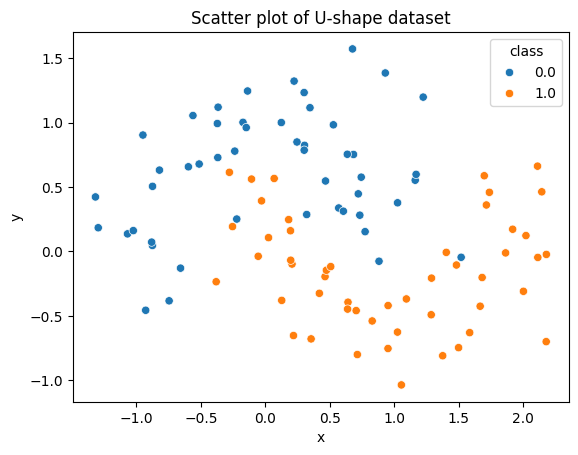

In [6]:
sns.scatterplot(data=df, x='x', y='y', hue='class')
plt.title("Scatter plot of U-shape dataset")

In [7]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [8]:
model = Sequential([
    Dense(10, activation='sigmoid', input_dim=2),
    Dense(1, activation='sigmoid')
])

d:\Programming\Deep_Learning_Concept\.tensorli\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',loss='binary_crossentropy', metrics=['accuracy']
)

history = model.fit(X,y,epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5685 - loss: 0.6789 - val_accuracy: 0.7000 - val_loss: 0.6620
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5700 - loss: 0.6766 - val_accuracy: 0.7000 - val_loss: 0.6610
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5802 - loss: 0.6757 - val_accuracy: 0.7000 - val_loss: 0.6600
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6334 - loss: 0.6716 - val_accuracy: 0.7000 - val_loss: 0.6588
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6226 - loss: 0.6730 - val_accuracy: 0.7000 - val_loss: 0.6578
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6422 - loss: 0.6721 - val_accuracy: 0.7000 - val_loss: 0.6568
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6265 - loss: 0.6718 - val_accuracy: 0.7000 - val_loss: 0.6558
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6680 - loss: 0.6696 - val_accuracy: 0.7000 - val_loss:

In [11]:
initialize_weight=model.get_weights()

In [12]:
initialize_weight

[array([[-0.79920024, -0.45714375,  0.8111528 ,  0.8770311 ,  0.20991416,
          0.83798575, -0.6953549 , -0.24729645,  0.06203249, -0.16920312],
        [ 0.56961507,  0.6375794 ,  0.39920408,  0.13629572,  0.7252394 ,
         -0.35022822,  0.8323454 , -0.28564212, -0.5181637 , -0.6863453 ]],
       dtype=float32),
 array([ 0.0728135 ,  0.00874951,  0.01158035, -0.03388512, -0.03796668,
        -0.07438463,  0.04923779, -0.02540564,  0.00777628,  0.03516154],
       dtype=float32),
 array([[-0.17281723],
        [-0.6459055 ],
        [ 0.22239405],
        [ 0.47002456],
        [-0.2886199 ],
        [ 0.40456754],
        [-0.3157477 ],
        [-0.12086404],
        [ 0.06587509],
        [ 0.14090265]], dtype=float32),
 array([0.01163678], dtype=float32)]

In [13]:
initialize_weight[0]=np.zeros(model.get_weights()[0].shape)
initialize_weight[1]=np.zeros(model.get_weights()[1].shape)
initialize_weight[2]=np.zeros(model.get_weights()[2].shape)
initialize_weight[3]=np.zeros(model.get_weights()[3].shape)


In [14]:
initialize_weight

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([0.])]

In [15]:
model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7992 - loss: 0.5860 - val_accuracy: 0.8000 - val_loss: 0.5506
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7562 - loss: 0.5893 - val_accuracy: 0.8000 - val_loss: 0.5493
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7250 - loss: 0.6010 - val_accuracy: 0.8000 - val_loss: 0.5480
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7713 - loss: 0.5886 - val_accuracy: 0.8000 - val_loss: 0.5467
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7869 - loss: 0.5879 - val_accuracy: 0.8000 - val_loss: 0.5453
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7947 - loss: 0.5830 - val_accuracy: 0.8000 - val_loss: 0.5440
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7908 - loss: 0.5834 - val_accuracy: 0.8000 - val_loss: 0.5426
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7884 - loss: 0.5851 - val_accuracy: 0.8000 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 3s 327us/step


<Axes: >

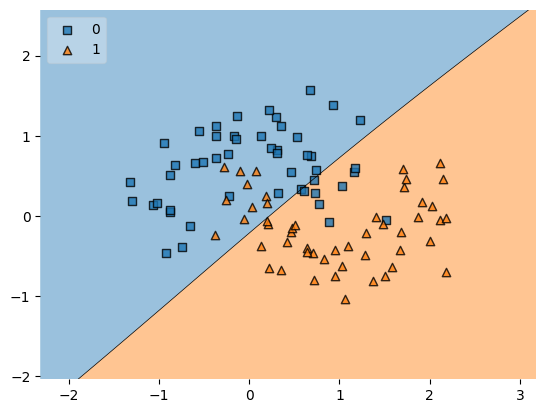

In [16]:
# %pip install mlxtend
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf=model, legend=2)